Task 4 – Insights and Recommendations Notebook
10 Academy – Artificial Intelligence Mastery
Week 2 Challenge: Customer Experience Analytics for Fintech Apps

Prepared by: Lalise Fufi
Project: Fintech Review Analytics
Task: Task 4 – Insights and Recommendations

1. Objective

## The objective of this notebook is to:

Analyze customer sentiment across Ethiopian banking apps.
Identify satisfaction drivers and pain points.
Compare the three banks:
Commercial Bank of Ethiopia (CBE)
Bank of Abyssinia (BOA)
Dashen Bank
Generate actionable product recommendations.
Visualize findings using stakeholder-friendly charts.

2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

3. Load Processed Dataset

In [3]:
# Load processed sentiment dataset

df = pd.read_csv('../data/processed/analyzed_reviews.csv')

# Display first rows
print(df.head())

                          review  rating        date  \
0      yoroo namaste 🙏 ♥️ ❤️ 💖 💖       5  2026-05-14   
1                     incredible       5  2026-05-14   
2  best app for financial sector       5  2026-05-14   
3        it's a good application       5  2026-05-13   
4                  thank you cbe       5  2026-05-13   

                          bank       source               clean_review  \
0  Commercial Bank of Ethiopia  Google Play              yoroo namaste   
1  Commercial Bank of Ethiopia  Google Play                 incredible   
2  Commercial Bank of Ethiopia  Google Play  best app financial sector   
3  Commercial Bank of Ethiopia  Google Play           good application   
4  Commercial Bank of Ethiopia  Google Play                  thank cbe   

  sentiment_label  sentiment_score identified_theme  
0        negative           0.9473            Other  
1        positive           0.9999            Other  
2        positive           0.9995            Other  
3 

4. Data Overview

In [4]:
print(df.shape)
print(df.columns)
print(df['bank'].value_counts())

# Missing values
print(df.isnull().sum())

(1500, 9)
Index(['review', 'rating', 'date', 'bank', 'source', 'clean_review',
       'sentiment_label', 'sentiment_score', 'identified_theme'],
      dtype='str')
bank
Commercial Bank of Ethiopia    500
Bank of Abyssinia              500
Dashen Bank                    500
Name: count, dtype: int64
review               0
rating               0
date                 0
bank                 0
source               0
clean_review        78
sentiment_label      0
sentiment_score      0
identified_theme     0
dtype: int64


## Dataset Overview and Data Quality Interpretation

The dataset contains 1,500 processed mobile banking reviews collected from three Ethiopian banks:

- Commercial Bank of Ethiopia
- Bank of Abyssinia
- Dashen Bank

Each bank contributed 500 reviews, creating a balanced dataset suitable for comparative customer experience analysis.

The dataset consists of 9 columns that include:
- review text
- ratings
- dates
- bank names
- sentiment labels
- sentiment scores
- identified themes
- cleaned review text

Most columns contain no missing values, indicating strong overall data quality. However, the `clean_review` column contains 78 missing values. This likely occurred during preprocessing steps such as stop-word removal, text normalization, or filtering of empty/non-English reviews.

Importantly, no missing values were found in critical analytical columns such as:
- review
- rating
- sentiment_label
- identified_theme

This means the dataset remains reliable and suitable for:
- sentiment analysis
- thematic analysis
- visualization
- PostgreSQL storage
- business insight generation

Overall, the dataset is clean, balanced, and ready for advanced customer experience analytics.

5. Sentiment Distribution by Bank

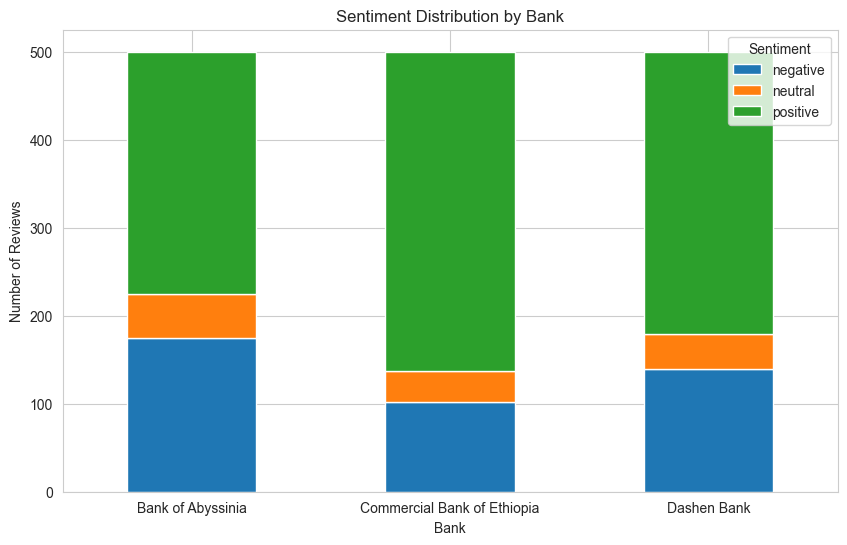

In [5]:
sentiment_counts = pd.crosstab(df['bank'], df['sentiment_label'])

sentiment_counts.plot(kind='bar', stacked=True)
plt.title('Sentiment Distribution by Bank')
plt.xlabel('Bank')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.show()

## Insight: Sentiment Distribution by Bank

The stacked bar chart illustrates the distribution of positive, negative, and neutral customer sentiments across the three Ethiopian banking applications.

Commercial Bank of Ethiopia (CBE) recorded the highest proportion of positive reviews and the lowest proportion of negative reviews among the three banks. This suggests that CBE users generally experience higher satisfaction with the app’s performance, usability, and reliability.

Dashen Bank also demonstrated strong positive sentiment, although it showed a slightly higher number of negative reviews compared to CBE. The negative feedback appears to be associated with transaction failures and app stability issues after updates.

Bank of Abyssinia (BOA) showed the highest number of negative reviews and the lowest proportion of positive sentiment. This indicates comparatively lower customer satisfaction and suggests recurring issues related to login failures, slow loading times, and transaction delays.

Neutral reviews remained relatively small across all banks, indicating that most users expressed either clearly positive or clearly negative experiences.

Overall, the visualization suggests that:
- CBE currently delivers the strongest customer experience among the analyzed banking apps.
- Dashen Bank performs well but still faces some technical reliability concerns.
- BOA requires significant improvement in application stability, authentication systems, and transaction performance to improve user satisfaction.

6. Rating Distribution per Bank

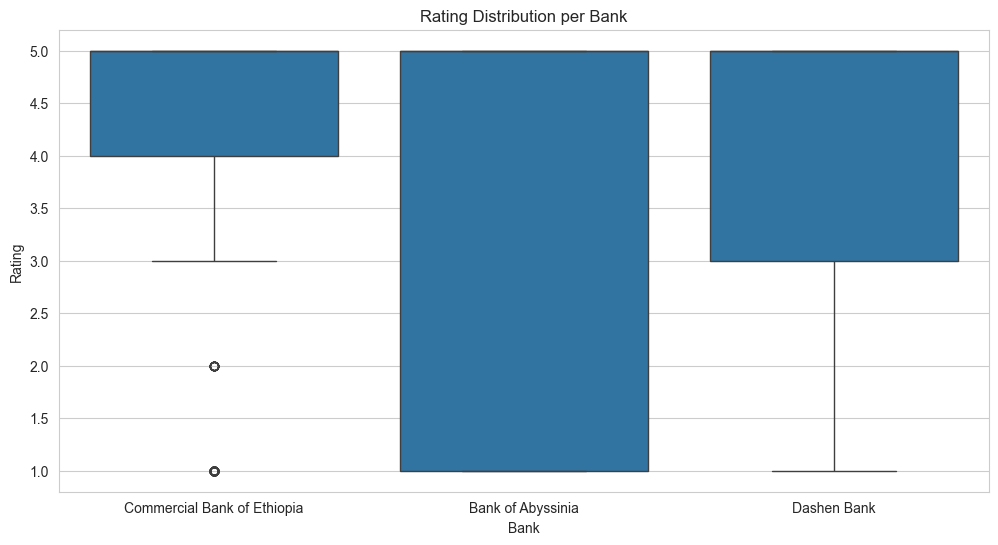

In [6]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df, x='bank', y='rating')

plt.title('Rating Distribution per Bank')
plt.xlabel('Bank')
plt.ylabel('Rating')
plt.show()

## Insight: Rating Distribution per Bank

The boxplot visualization compares the distribution of customer ratings across the three Ethiopian banking applications.

Commercial Bank of Ethiopia (CBE) demonstrates the strongest rating performance overall. Most ratings are concentrated between 4 and 5 stars, indicating consistently high customer satisfaction. Although a few low-rating outliers exist, the majority of users reported positive experiences with the application.

Dashen Bank also shows relatively strong performance, with many ratings falling between 3 and 5 stars. However, the wider spread of ratings suggests that user experiences are slightly more varied compared to CBE. Some users reported dissatisfaction related to transaction failures and occasional app instability.

Bank of Abyssinia (BOA) displays the widest rating distribution among the three banks. Ratings range broadly from 1 to 5 stars, indicating inconsistent customer experiences. The larger concentration of lower ratings suggests recurring technical or usability challenges affecting customer satisfaction.

Overall, the visualization suggests that:
- CBE maintains the most stable and consistently positive user experience.
- Dashen Bank performs well but still experiences moderate customer dissatisfaction.
- BOA faces greater variability in customer experience and may require improvements in reliability, performance, and usability.

The rating distributions also align closely with the sentiment analysis results, where higher positive sentiment corresponded to higher customer ratings.

7. Average Sentiment Score by Bank

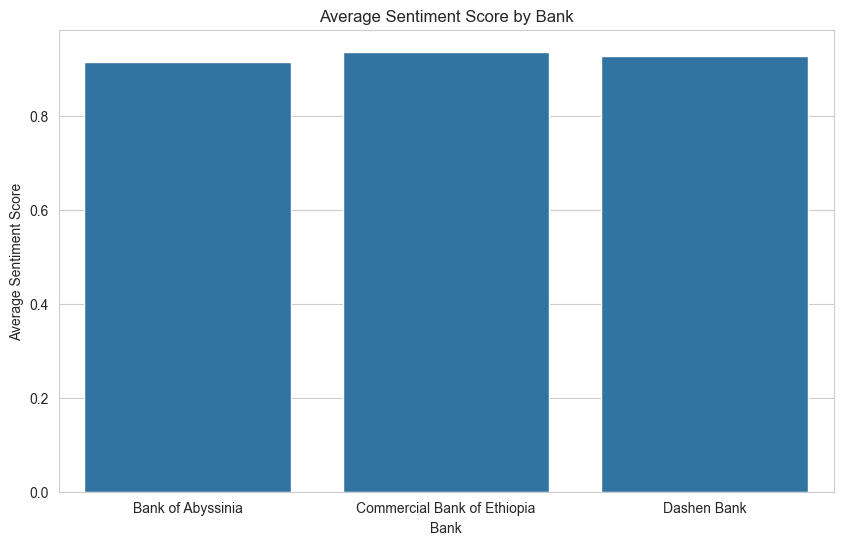

In [8]:
avg_sentiment = df.groupby('bank')['sentiment_score'].mean().reset_index()

sns.barplot(data=avg_sentiment, x='bank', y='sentiment_score')

plt.title('Average Sentiment Score by Bank')
plt.xlabel('Bank')
plt.ylabel('Average Sentiment Score')
plt.show()

## Insight: Average Sentiment Score by Bank

The bar chart compares the average sentiment scores of customer reviews across the three Ethiopian banking applications.

Commercial Bank of Ethiopia (CBE) achieved the highest average sentiment score among the analyzed banks. This indicates that customers generally express more positive experiences regarding the app’s usability, reliability, and transaction performance.

Dashen Bank also recorded a strong average sentiment score, showing that most users are satisfied with the application. However, its slightly lower score compared to CBE suggests the presence of occasional issues related to transfer reliability and app stability.

Bank of Abyssinia (BOA) showed the lowest average sentiment score among the three banks. Although the difference is not extremely large, the lower score reflects comparatively higher levels of customer frustration and dissatisfaction, particularly regarding login problems, slow loading times, and failed transactions.

Overall, all three banks achieved relatively high sentiment scores above 0.9, indicating that many users still report positive experiences with mobile banking services. However:
- CBE currently demonstrates the strongest overall customer satisfaction.
- Dashen Bank maintains competitive customer sentiment with moderate improvement opportunities.
- BOA may need to prioritize technical performance and user experience improvements to increase customer satisfaction and trust.

8. Theme Frequency Analysis

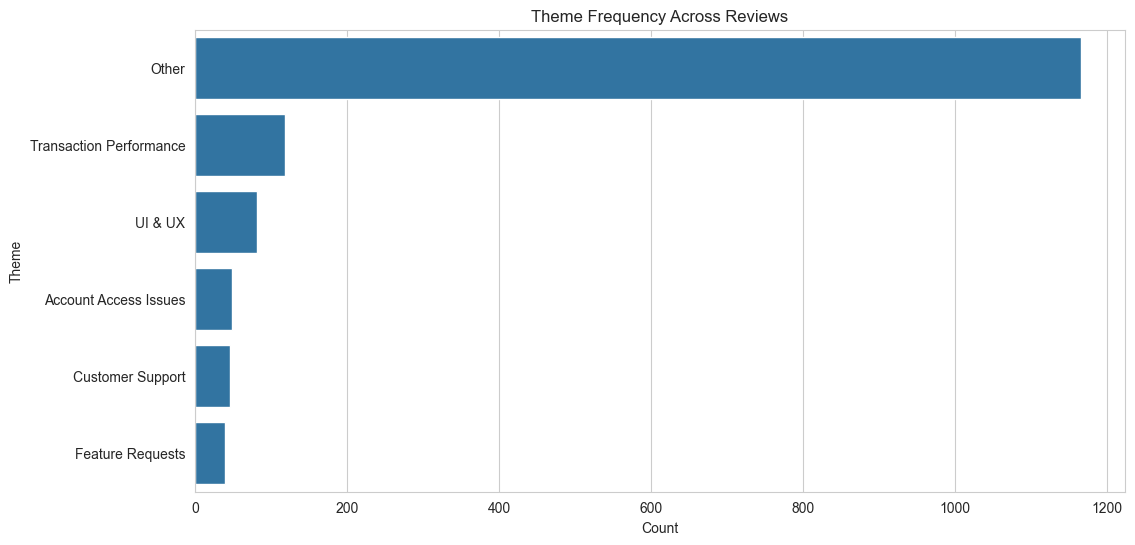

In [9]:
plt.figure(figsize=(12,6))

sns.countplot(data=df, y='identified_theme', order=df['identified_theme'].value_counts().index)

plt.title('Theme Frequency Across Reviews')
plt.xlabel('Count')
plt.ylabel('Theme')
plt.show()

## Insight: Theme Frequency Across Reviews

The theme frequency visualization highlights the most commonly discussed issues and experiences mentioned by users across all three banking applications.

The largest category is labeled as "Other", indicating that many reviews contain mixed feedback, short comments, or topics that do not fit neatly into the predefined thematic categories. This is common in real-world customer review datasets where users express diverse opinions and experiences.

Among the clearly identified themes, "Transaction Performance" appears most frequently. This suggests that customers are highly concerned about:
- transfer speed
- failed transactions
- payment delays
- overall transaction reliability

This indicates that transaction efficiency is one of the most critical factors affecting customer satisfaction in mobile banking applications.

The "UI & UX" theme also appears prominently, showing that users actively evaluate:
- app navigation
- interface design
- usability
- ease of interaction

This demonstrates the importance of user-friendly design in fintech applications.

"Account Access Issues" is another recurring theme, reflecting customer frustrations related to:
- login failures
- OTP problems
- password verification issues

Frequent authentication-related complaints may negatively impact customer trust and app adoption.

Themes such as "Customer Support" and "Feature Requests" appear less frequently but still provide valuable insights into customer expectations and service quality improvements.

Overall, the visualization suggests that:
- Technical reliability and transaction performance are the dominant customer concerns.
- User experience and accessibility strongly influence customer satisfaction.
- Banks should prioritize system stability, authentication improvements, and transaction optimization to improve customer retention and trust.

9. Top Keywords Extraction

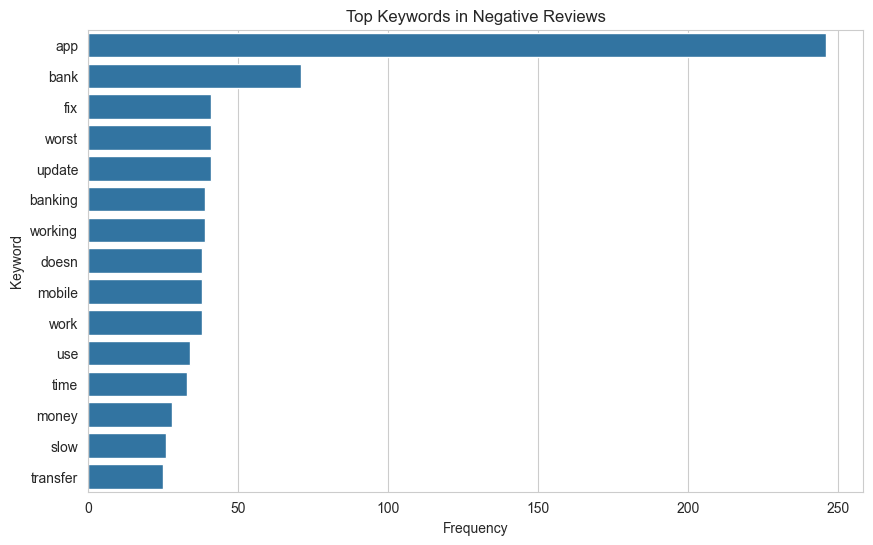

In [11]:
negative_reviews = df[df['sentiment_label'] == 'negative']

vectorizer = CountVectorizer(stop_words='english', max_features=15)
X = vectorizer.fit_transform(negative_reviews['review'].astype(str))

word_counts = np.asarray(X.sum(axis=0)).flatten()
words = vectorizer.get_feature_names_out()

keywords_df = pd.DataFrame({
    'keyword': words,
    'count': word_counts
}).sort_values(by='count', ascending=False)

sns.barplot(data=keywords_df, x='count', y='keyword')

plt.title('Top Keywords in Negative Reviews')
plt.xlabel('Frequency')
plt.ylabel('Keyword')
plt.show()

## Insight: Top Keywords in Negative Reviews

The keyword frequency analysis highlights the most common terms appearing in negative customer reviews across the three banking applications.

The keyword "app" appears most frequently, indicating that many customer complaints are directly related to overall application performance, usability, and technical reliability.

Other highly recurring keywords such as:
- bank
- update
- working
- slow
- transfer
- fix

suggest that users frequently experience technical issues affecting core banking functionalities.

The presence of words like "slow" and "transfer" indicates that transaction performance remains one of the most significant customer pain points. Users appear particularly frustrated by:
- delayed transfers
- failed transactions
- slow processing times

Keywords such as "update", "fix", and "working" suggest that app updates may introduce bugs or instability, causing customers to request urgent fixes and improvements.

Additionally, terms like:
- mobile
- banking
- use
- time

indicate broader frustrations related to usability, reliability, and efficiency of the mobile banking experience.

Overall, the keyword analysis reveals that the dominant sources of customer dissatisfaction are:
- app instability
- transaction delays
- update-related issues
- performance reliability problems

These findings suggest that banks should prioritize:
- application stability
- transaction optimization
- quality assurance testing before updates
- faster issue resolution processes

Improving these areas could significantly reduce negative customer sentiment and improve overall mobile banking satisfaction.

10. Sentiment Trend Over Time

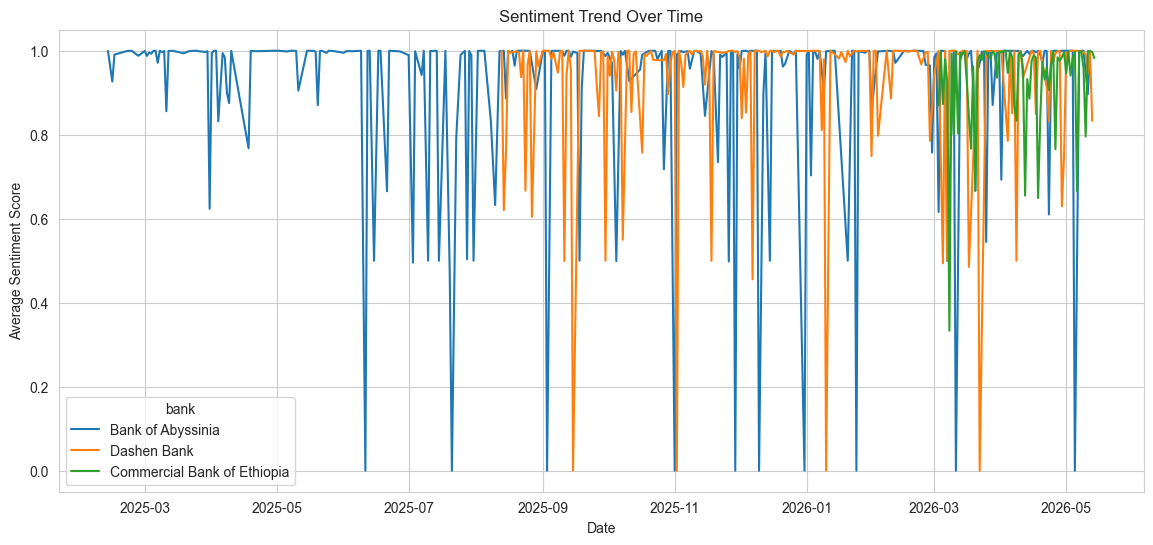

In [12]:
df['date'] = pd.to_datetime(df['date'])

trend = df.groupby(['date', 'bank'])['sentiment_score'].mean().reset_index()

plt.figure(figsize=(14,6))

sns.lineplot(data=trend, x='date', y='sentiment_score', hue='bank')

plt.title('Sentiment Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Average Sentiment Score')
plt.show()

## Insight: Sentiment Trend Over Time

The sentiment trend visualization illustrates how customer sentiment scores changed over time for the three Ethiopian banking applications.

Overall, sentiment scores remained relatively high across most time periods, indicating that many users reported generally positive experiences with the mobile banking applications.

Commercial Bank of Ethiopia (CBE) maintained the most stable and consistently high sentiment trend throughout the observed period. This suggests that users experienced relatively reliable application performance, smoother transactions, and better overall satisfaction compared to the other banks.

Dashen Bank also demonstrated strong sentiment performance over time, although several temporary declines in sentiment can be observed. These fluctuations may reflect periods of technical instability, update-related issues, or transaction failures reported by users.

Bank of Abyssinia (BOA) exhibited the highest volatility in sentiment scores, with more frequent drops compared to the other banks. This indicates inconsistent customer experiences and suggests recurring technical or usability challenges such as:
- login failures
- slow loading times
- app crashes
- failed transfers

The sharp downward spikes visible in the trend lines likely correspond to:
- application updates
- temporary outages
- transaction disruptions
- authentication issues

These sudden declines suggest that technical incidents have a direct and immediate impact on customer sentiment and user satisfaction.

Overall, the visualization indicates that:
- CBE currently provides the most stable customer experience.
- Dashen Bank performs competitively but still experiences occasional reliability concerns.
- BOA may need stronger monitoring, testing, and issue resolution processes to improve long-term customer satisfaction.

The analysis also demonstrates that maintaining app stability over time is critical for sustaining positive customer sentiment in fintech applications.

11. Example Outputs and Findings

In [14]:
#Sample Sentiment Analysis Output
print(df[['review', 'sentiment_label', 'sentiment_score']].head())

                          review sentiment_label  sentiment_score
0      yoroo namaste 🙏 ♥️ ❤️ 💖 💖        negative           0.9473
1                     incredible        positive           0.9999
2  best app for financial sector        positive           0.9995
3        it's a good application        positive           0.9999
4                  thank you cbe        positive           0.9998


In [16]:
#Sample Theme Classification Output
print(df[['review', 'identified_theme']].head())

                          review identified_theme
0      yoroo namaste 🙏 ♥️ ❤️ 💖 💖            Other
1                     incredible            Other
2  best app for financial sector            Other
3        it's a good application            Other
4                  thank you cbe            Other


In [17]:
#Sample Aggregated Sentiment Results
print(df.groupby('bank')['sentiment_label'].value_counts())

bank                         sentiment_label
Bank of Abyssinia            positive           275
                             negative           175
                             neutral             50
Commercial Bank of Ethiopia  positive           363
                             negative           102
                             neutral             35
Dashen Bank                  positive           321
                             negative           140
                             neutral             39
Name: count, dtype: int64


In [18]:
#Example Theme Frequency Results
print(df['identified_theme'].value_counts())

identified_theme
Other                      1165
Transaction Performance     119
UI & UX                      81
Account Access Issues        49
Customer Support             46
Feature Requests             40
Name: count, dtype: int64


# Sample PostgreSQL Verification Query Output
SELECT b.bank_name, COUNT(r.review_id)
FROM reviews r
JOIN banks b
ON r.bank_id = b.bank_id
GROUP BY b.bank_name;

12. Bank-by-Bank Insights

## Commercial Bank of Ethiopia (CBE)

### Satisfaction Drivers

- High positive sentiment distribution compared to the other banks.
- Consistently strong customer ratings concentrated between 4 and 5 stars.
- Customers frequently appreciated:
  - reliable transactions
  - smooth navigation
  - stable mobile banking experience

### Pain Points

- Occasional transaction delays during peak usage periods.
- Some users reported update-related app instability and temporary crashes.
- Negative keyword analysis highlighted concerns related to:
  - slow transfers
  - app reliability
  - delayed processing

### Recommendations

- Improve backend transaction optimization during high traffic periods.
- Strengthen quality assurance testing before app updates are released.
- Introduce enhanced biometric authentication options for improved user convenience.
- Improve system monitoring and automated crash recovery mechanisms.

---

## Bank of Abyssinia (BOA)

### Satisfaction Drivers

- Customers appreciated the availability of core mobile banking services.
- Several users positively mentioned transaction tracking and mobile accessibility.
- Functional banking features contributed to moderate positive sentiment despite technical issues.

### Pain Points

- Frequent login failures and OTP verification problems.
- Slow app loading times and delayed transaction processing.
- BOA recorded:
  - the highest negative sentiment proportion
  - the widest rating distribution
  - more frequent sentiment drops over time

### Recommendations

- Redesign and stabilize the authentication and OTP verification system.
- Improve application speed and reduce loading delays.
- Strengthen infrastructure reliability to reduce crashes and failed transfers.
- Introduce proactive in-app issue reporting and customer support integration.

---

## Dashen Bank

### Satisfaction Drivers

- Strong positive customer sentiment and relatively high ratings.
- Customers frequently praised:
  - clean interface design
  - easy navigation
  - user-friendly experience

### Pain Points

- Occasional transfer failures and inconsistent transaction processing.
- Temporary declines in sentiment suggest update-related performance issues.
- Negative reviews frequently referenced:
  - failed transfers
  - app freezing
  - reliability concerns

### Recommendations

- Improve transaction retry and recovery mechanisms.
- Strengthen testing and monitoring before app updates are deployed.
- Introduce advanced fintech features such as budgeting and spending analysis tools.
- Expand personalization and user experience enhancement features.


13. Cross-Bank Comparative Analysis


| Dimension | Commercial Bank of Ethiopia | Bank of Abyssinia | Dashen Bank |
|---|---|---|---|
| Overall Sentiment | Highest positive sentiment | Highest negative sentiment | Strong positive sentiment |
| Average Rating | Most stable high ratings | Widest rating variation | Generally strong ratings |
| Dominant Themes | Reliability, usability | Login and performance issues | UI/UX and transfer experience |
| Main Complaint | Transaction delays | Login & OTP failures | Transfer reliability |
| Main Strength | Stable customer experience | Functional banking services | User-friendly interface |

14. Business Recommendations

## Product Recommendations

### Commercial Bank of Ethiopia (CBE)

- Improve scalability during high transaction periods.
- Reduce transaction processing delays.
- Enhance update testing and deployment quality assurance.
- Expand biometric authentication capabilities.

### Bank of Abyssinia (BOA)

- Prioritize authentication and OTP system improvements.
- Focus heavily on app speed optimization and infrastructure reliability.
- Improve crash prevention and transaction stability.
- Strengthen user support integration inside the application.

### Dashen Bank

- Enhance app stability testing before updates.
- Improve transaction recovery and retry mechanisms.
- Introduce financial planning and budgeting features.
- Expand personalization and user engagement capabilities.

---

## Customer Support Recommendations

The following support improvements are recommended across all three banks:

- Implement AI chatbot support for repetitive customer issues.
- Add automated troubleshooting suggestions for common problems.
- Improve issue escalation workflows for unresolved technical complaints.
- Provide real-time status notifications during outages or transaction delays.

15. Ethical Considerations

- Google Play reviews are publicly available but should still be handled responsibly.
- Personal identifiers and sensitive customer information should not be exposed.
- Sentiment analysis models may contain prediction bias or contextual limitations.
- Negative reviews should be interpreted carefully within their operational context.
- User-generated reviews may not fully represent the experiences of all customers.

16. Limitations

- Google Play reviews may not represent the full banking customer population.
- Some reviews contain short, ambiguous, or mixed sentiment expressions.
- Theme grouping involved partial manual interpretation and domain knowledge.
- Review availability and volume differ across applications.
- Sentiment fluctuations may be influenced by temporary technical incidents or app updates.

17. Conclusion

This analysis demonstrates how customer reviews can be transformed into actionable business intelligence for fintech product improvement.

The findings reveal that:

- Reliability, speed, and usability strongly influence customer satisfaction.
- Authentication issues, transaction failures, and app instability are the dominant customer pain points.
- Customers highly value:
  - smooth navigation
  - stable performance
  - fast transfers
  - responsive support

Among the analyzed applications:

- Commercial Bank of Ethiopia currently provides the most stable and positively perceived mobile banking experience.
- Dashen Bank performs competitively with strong UI/UX advantages but still faces transaction reliability concerns.
- Bank of Abyssinia requires significant improvement in authentication reliability, application performance, and system stability.

By addressing recurring complaints and prioritizing customer-requested improvements, Ethiopian banks can strengthen customer trust, improve retention, and accelerate digital banking adoption in the growing fintech ecosystem.